In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator
from src.models import PersistenceModel, ClimateologyModel

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [3]:
from src.dataloading import BaseLineDataLoaderManager
from src.models.base.basemodel import BaseModel

baselinedata = BaseLineDataLoaderManager(data_orchestrator)

In [6]:
print(climateology2)

<PersistenceModel(
    model name : persistence_model_v2

    ----STATUS---
    forecasted : <PredictionManager(PredictionCollection at test)>
)>


- make persistencemodel, climateology model rely on baselinedataloader
- make climascale model, that relies on baselinedataloader

- make sequentialization in deepdataloader

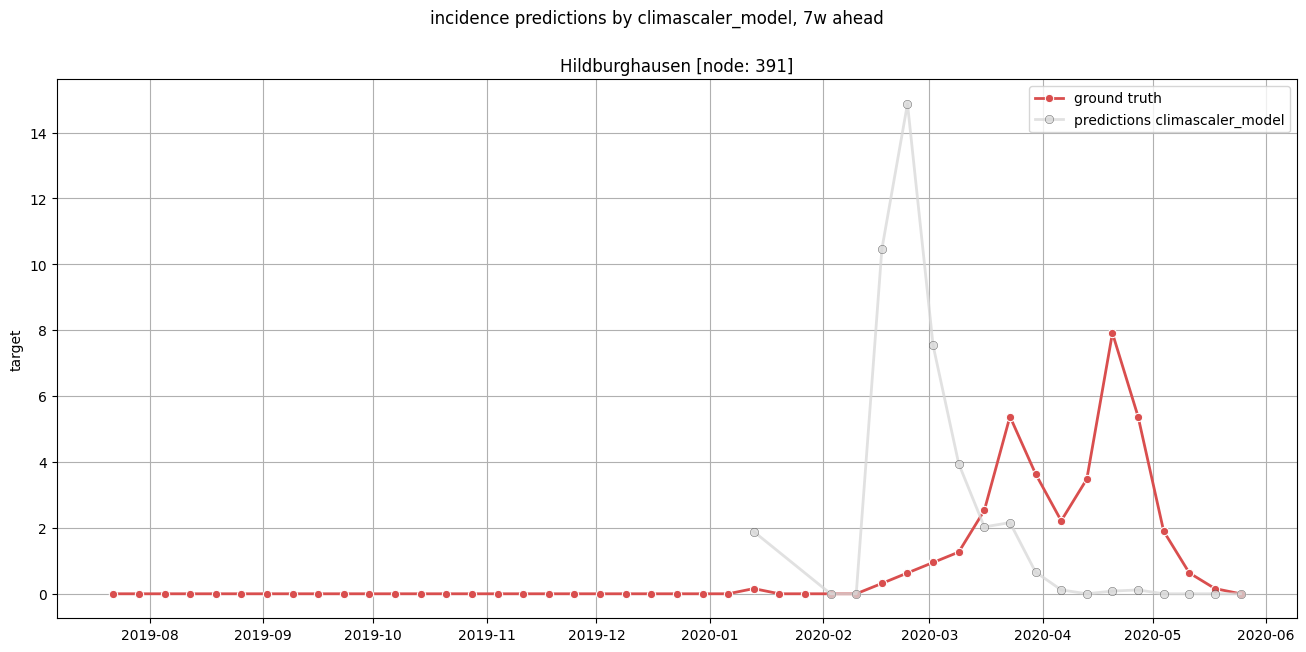

In [160]:
climateology2 = ClimaScaler(baselinedata)
climateology2.forecast('test')
climateology2.show_forecasts(391).show()

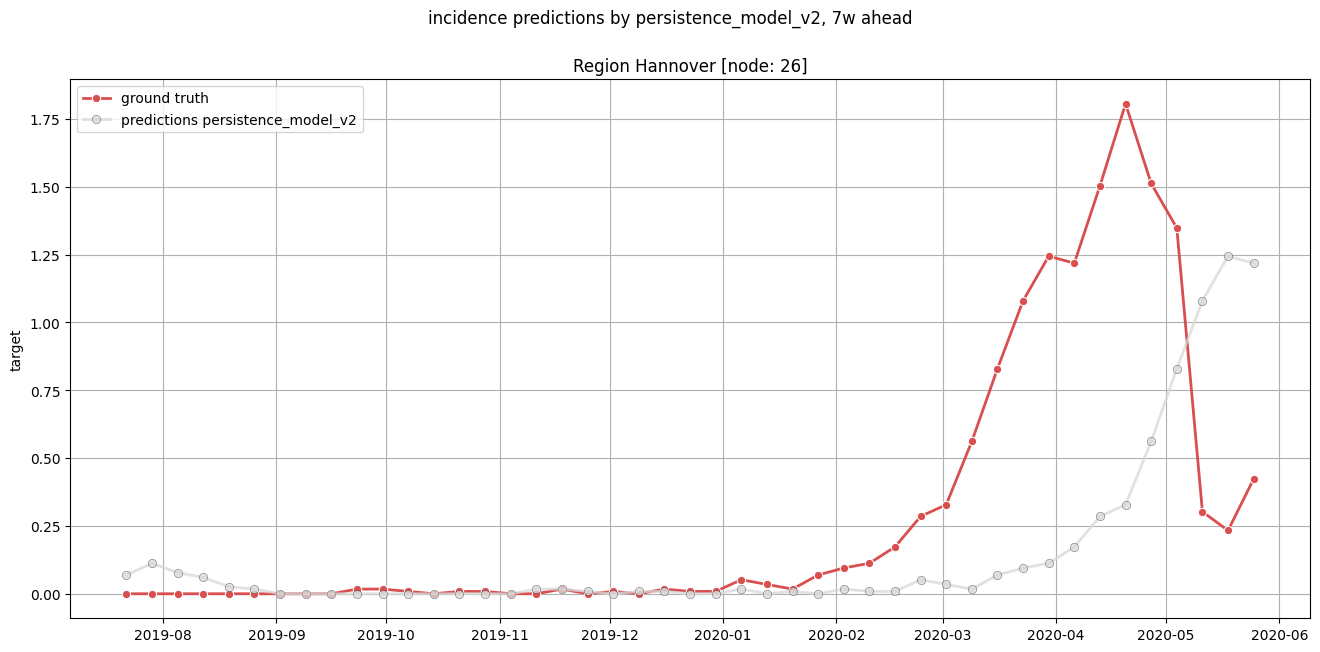

In [5]:
climateology2 = PersistenceModel(baselinedata)
climateology2.forecast('test')
climateology2.show_forecasts(26).show()